<a href="https://colab.research.google.com/github/joelya9-design/Yield-curve/blob/main/Yield_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#first step as alway import the libraries needed
import pandas as pd #for using and creating dataframes
import matplotlib.pyplot as plt #plotting data as visuals
import numpy as np #important mathematical functions

import pandas_datareader as pdr #connects to external data sources to read them
from datetime import datetime #easily select dates from our panda dataframes

2. download FRED data (federal reserve economic data)

In [26]:
start=datetime(2020,1,1) #create variable for data range using datetime function
end=datetime(2026,9,14)
pdr.DataReader('DGS10','fred',start,end)
#use pdr function to dowload the FED 10 year gov bond
# 'fred' (federal reserve economic data), 'DGS10' (daily gov securities 10 year)

,DGS10
DATE,
2020-01-01,NaN
2020-01-02,1.88
2020-01-03,1.80
2020-01-06,1.81
2020-01-07,1.83
...,...
2026-09-07,NaN
2026-09-08,4.80
2026-09-09,4.83


3. dowload all Fed maturties

In [27]:
start=datetime(2020,1,1)
end=datetime(2026,9,14)
yields=pdr.DataReader(('DGS3MO','DGS2','DGS5','DGS10','DGS30'),'fred',start,end).dropna()
#downloaded all Fed maturities and used .dropna() to remove blanc cells
print(yields)

            DGS3MO  DGS2  DGS5  DGS10  DGS30
DATE                                        
2020-01-02    1.54  1.58  1.67   1.88   2.33
2020-01-03    1.52  1.53  1.59   1.80   2.26
2020-01-06    1.56  1.54  1.61   1.81   2.28
2020-01-07    1.54  1.54  1.62   1.83   2.31
2020-01-08    1.54  1.58  1.67   1.87   2.35
...            ...   ...   ...    ...    ...
2026-09-04    3.91  4.37  4.54   4.78   5.24
2026-09-08    3.94  4.39  4.57   4.80   5.25
2026-09-09    3.95  4.43  4.61   4.83   5.28
2026-09-10    4.00  4.56  4.75   4.95   5.37
2026-09-11    4.07  4.63  4.78   4.96   5.35

[1675 rows x 5 columns]


4. create todays yield curve by using function to select a single row

In [28]:
#create variable for extracting todays yields for each maturity
today_yields=yields.iloc[-1]
#.loc[] function to index row based on string name
# or for most recent trading day, index the last row by using .iloc[-1]
print(today_yields)

DGS3MO    4.07
DGS2      4.63
DGS5      4.78
DGS10     4.96
DGS30     5.35
Name: 2026-09-11 00:00:00, dtype: float64


5. create todays (10-09-2026) yield curve

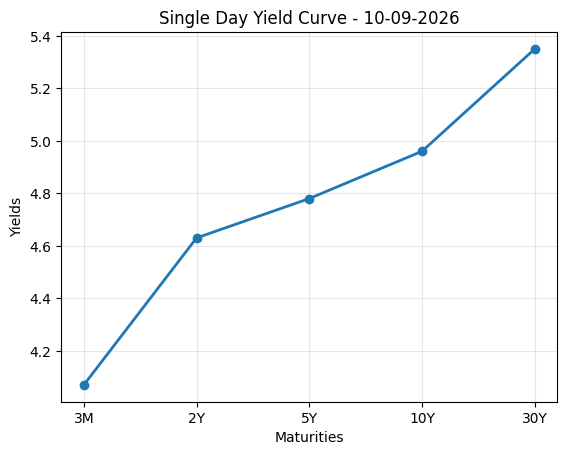

In [29]:
#use matplot.lib to create a line chart for the yield curve

#create x axis variables
maturities=['3M','2Y','5Y','10Y','30Y']
#use plt.plot to plot data
# improve disply with functions below
# marker (creates a dot for each point), linewidth (increases linewidth for visibility)
plt.plot(maturities,today_yields, marker='o',linewidth=2)


#add chart labels and heading
plt.title('Single Day Yield Curve - 10-09-2026')
plt.xlabel('Maturities')
plt.ylabel('Yields')
plt.grid(True,alpha=0.3)
plt.savefig('Sep_2026_Normal.png',dpi=150,bbox_inches='tight')
#display
plt.show()

6. compare current yield curve to COVID rate hiking cycle

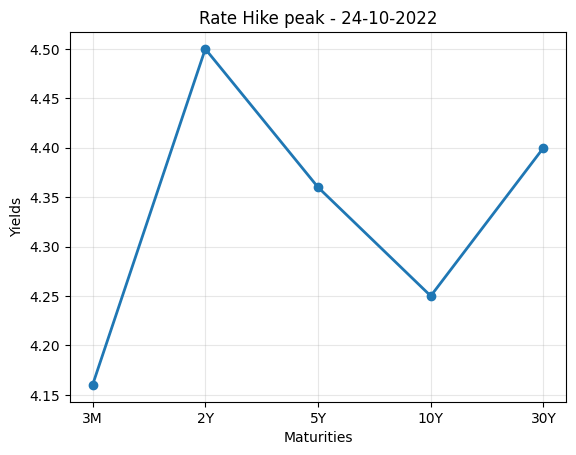

In [34]:
#extract the row needed
hike_peak_yields=yields.loc['2022-10-24']

#plot and label chart
plt.plot(maturities,hike_peak_yields,marker='o',linewidth=2)
plt.title('Rate Hike peak - 24-10-2022')
plt.xlabel('Maturities')
plt.ylabel('Yields')
plt.grid(True,alpha=0.3)
plt.savefig('Rate_Hike_Peak_2022.png',dpi=150,bbox_inches='tight')
plt.show()

7. compare both yield curves using a line chart with both plots

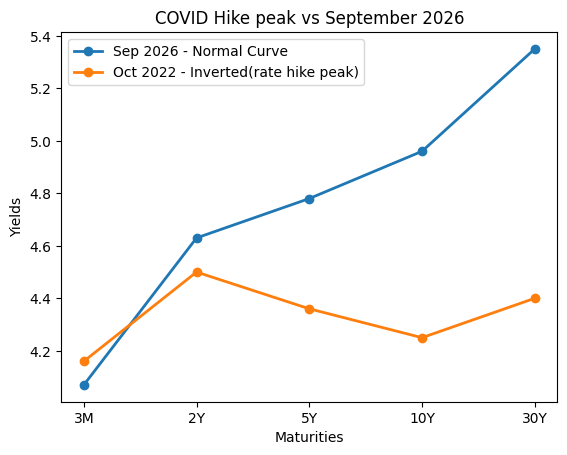

In [31]:
#to plot two line simply use plt.plot() twice
# label= function allows to create a label for the plotted line
plt.plot(maturities,today_yields,marker='o',linewidth=2, label='Sep 2026 - Normal Curve')
plt.plot(maturities,hike_peak_yields,marker='o',linewidth=2, label='Oct 2022 - Inverted(rate hike peak)')
plt.title('COVID Hike peak vs September 2026')
plt.xlabel('Maturities')
plt.ylabel('Yields')
#use legend function automatically picks up labels
plt.legend()
plt.show()

8.plot covid 2020 near zero rate cuts

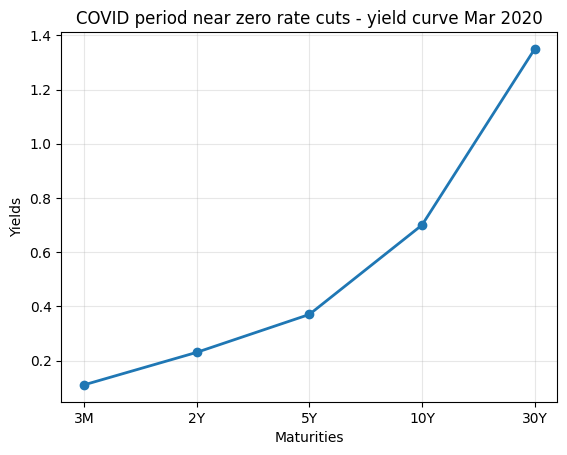

In [32]:
near_zero_yields=yields.loc['2020-03-31']
plt.plot(maturities,near_zero_yields,marker='o',linewidth=2)
plt.title('COVID period near zero rate cuts - yield curve Mar 2020')
plt.xlabel('Maturities')
plt.ylabel('Yields')
plt.grid(True,alpha=0.3)
plt.savefig('Rate_Cut_2020.png',dpi=150,bbox_inches='tight')
plt.show()

9.compare the two yields against the near zero rate cuts of 2020

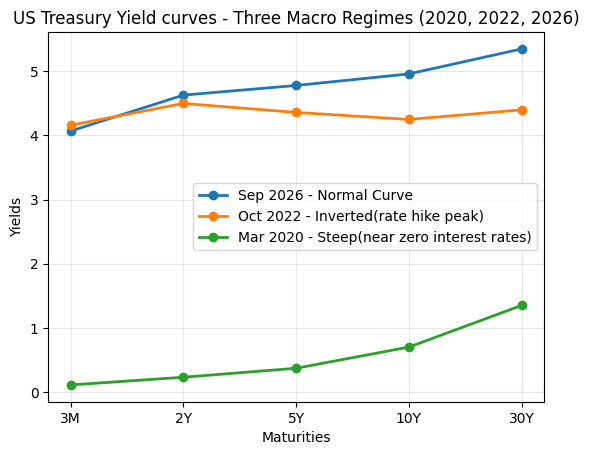

In [33]:
#plot all lines together
plt.plot(maturities,today_yields,marker='o',linewidth=2, label='Sep 2026 - Normal Curve')
plt.plot(maturities,hike_peak_yields,marker='o',linewidth=2, label='Oct 2022 - Inverted(rate hike peak)')
plt.plot(maturities,near_zero_yields,marker='o',linewidth=2,label='Mar 2020 - Steep(near zero interest rates)')

plt.title('US Treasury Yield curves - Three Macro Regimes (2020, 2022, 2026)')
plt.xlabel('Maturities')
plt.ylabel('Yields')
#use legend function automatically picks up labels
plt.legend()
plt.grid(True,alpha=0.3)#creates gri lines in chart for readability
plt.savefig('Yield_curve_comparison.png',dpi=150,bbox_inches='tight')
plt.show()